In [ ]:
import kagglehub

path = kagglehub.dataset_download("shrutimechlearn/churn-modelling")

print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'churn-modelling' dataset.
Dataset downloaded to: /kaggle/input/churn-modelling


In [ ]:
import os

print(os.listdir(path))

['Churn_Modelling.csv']


In [ ]:
import pandas as pd
import os

file_path = os.path.join(path, "Churn_Modelling.csv")

df = pd.read_csv(file_path)

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
X = df.iloc[:, 3:13]
y = df.iloc[:, 13]

In [ ]:
geography = pd.get_dummies(df["Geography"], drop_first=True,dtype=int)
gender = pd.get_dummies(df["Gender"], drop_first=True,dtype=int)

In [ ]:
X = pd.concat([X, geography, gender], axis=1)
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,France,Female,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1,0


In [ ]:
X = X.drop(["Geography", "Gender"], axis=1)
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LeakyReLU,ReLUeLU
from keras.layers import Dropout



In [ ]:
classifier = Sequential()

In [ ]:
classifier.add(Dense(units=10, kernel_initializer="he_uniform", activation="relu", input_dim=11))
classifier.add(Dropout(0.3))
classifier.add(Dense(units=20, kernel_initializer="he_uniform", activation="relu"))
classifier.add(Dropout(0.4))
classifier.add(Dense(units=1, kernel_initializer="glorot_uniform", activation="sigmoid"))

classifier.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

model_history = classifier.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=50)


Epoch 1/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8127 - loss: 0.5121 - val_accuracy: 0.8523 - val_loss: 0.4010
Epoch 2/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8416 - loss: 0.4186 - val_accuracy: 0.8485 - val_loss: 0.3909
Epoch 3/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8412 - loss: 0.4099 - val_accuracy: 0.8493 - val_loss: 0.3856
Epoch 4/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8481 - loss: 0.4017 - val_accuracy: 0.8501 - val_loss: 0.3916
Epoch 5/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8487 - loss: 0.3920 - val_accuracy: 0.8429 - val_loss: 0.3801
Epoch 6/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8477 - loss: 0.3894 - val_accuracy: 0.8546 - val_loss: 0.3802
Epoch 7/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8472 - loss: 0.3906 - val_accuracy: 0.8501 - val_loss: 0.3798
Epoch 8/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8537 - loss: 0.3853 - val_accuracy: 0.

In [ ]:
print(model_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


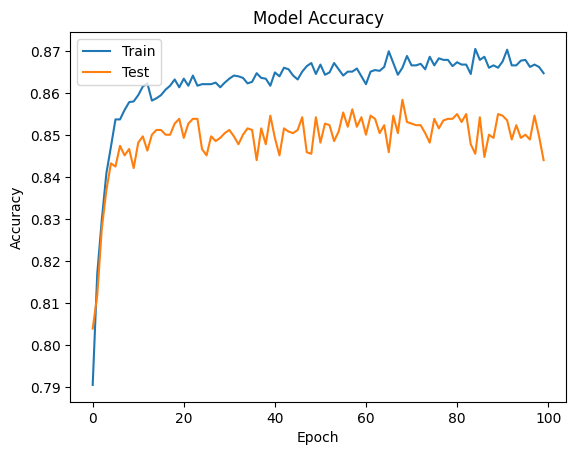

In [ ]:
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

In [ ]:
y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[1469,  126],
       [ 175,  230]])

In [ ]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred, y_test)
score

0.8495